# GSAM Detection Notebook

This notebook provides a simple interface to get vocabulary and detect_parts results for a given image using the GSAM detection pipeline.

## Features:
- Load image from file path
- Get vocabulary using OpenAI API
- Detect parts using Grounded SAM
- Visualize results

## Usage:
1. Set your image path in the configuration cell
2. Run all cells
3. View vocabulary and detection results


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import sys
import random
import numpy as np
import openai
import logging
from typing import Dict, List, Tuple, Any, Optional
from PIL import Image
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path

# Import necessary components from batch_gsam_segmentation.py
# Get the current working directory and navigate to project root
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
project_root = Path(project_root).resolve()
sys.path.append(str(project_root / 'src'))
os.chdir(str(project_root))
# os.chdir(str(project_root / 'jhpark/image-artifacts/src'))

print(f"📁 Added to sys.path: {project_root}")

from pipeline import GSAMDetector
from pipeline.prompts import get_entity_subentities, get_entity_subentities_new, MoneyManager

print("✅ All imports successful!")


📁 Added to sys.path: /home/jhpark/image-artifacts/src


✅ All imports successful!


## Configuration

Set your image path and detection settings here:


In [3]:
# Configuration
import random

# GSAM Detector Configuration (optional - uses defaults if None)
CONFIG = {
    'grounding_config_file': 'GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py',
    'grounding_checkpoint': 'weight/groundingdino_swint_ogc.pth',
    'sam_version': 'vit_h',
    'sam_checkpoint': 'weight/sam_vit_h_4b8939.pth',
    'sam_hq_checkpoint': 'weight/sam_hq_vit_h.pth',
    'use_sam_hq': True,
    'box_threshold': 0.3,
    'text_threshold': 0.25,
    'bert_base_uncased_path': None,
    'device': 'cuda'
}

print(f"🔧 Using device: {CONFIG['device']}")


🔧 Using device: cuda


## Helper Functions


In [4]:
def load_image_from_path(image_path: str) -> np.ndarray:
    """
    Load image from file path and convert to numpy array.
    
    Args:
        image_path: Path to the image file
        
    Returns:
        Image as numpy array
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    image = Image.open(image_path)
    if image.mode != 'RGB':
        image = image.convert('RGB')
    
    return np.array(image)

print("✅ Image loading function defined")


✅ Image loading function defined


In [5]:
def setup_gsam_detector(config: Optional[Dict[str, Any]] = None) -> GSAMDetector:
    """
    Initialize GSAM detector with default or provided configuration.
    
    Args:
        config: Optional configuration dictionary
        
    Returns:
        Initialized GSAMDetector instance
    """
    default_config = {
        'grounding_config_file': '../GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py',
        'grounding_checkpoint': '../weight/groundingdino_swint_ogc.pth',
        'sam_version': 'vit_h',
        'sam_checkpoint': '../weight/sam_hq_vit_h.pth',
        'sam_hq_checkpoint': None,
        'use_sam_hq': False,
        'box_threshold': 0.3,
        'text_threshold': 0.25,
        'bert_base_uncased_path': None,
        'device': 'cuda'
    }
    
    if config:
        default_config.update(config)
    
    return GSAMDetector(
        grounding_config_file=default_config['grounding_config_file'],
        grounding_checkpoint=default_config['grounding_checkpoint'],
        sam_version=default_config['sam_version'],
        sam_checkpoint=default_config['sam_checkpoint'],
        sam_hq_checkpoint=default_config['sam_hq_checkpoint'],
        use_sam_hq=default_config['use_sam_hq'],
        box_threshold=default_config['box_threshold'],
        text_threshold=default_config['text_threshold'],
        bert_base_uncased_path=default_config['bert_base_uncased_path'],
        device=default_config['device'],
        openai_client=openai.OpenAI()
    )

gsam_detector = setup_gsam_detector(CONFIG)

final text_encoder_type: bert-base-uncased


<All keys matched successfully>


In [6]:
val2017_dir = "/data3/jhpark/coco/train2017"
image_files = [f for f in os.listdir(val2017_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

In [7]:
len(image_files)

118287

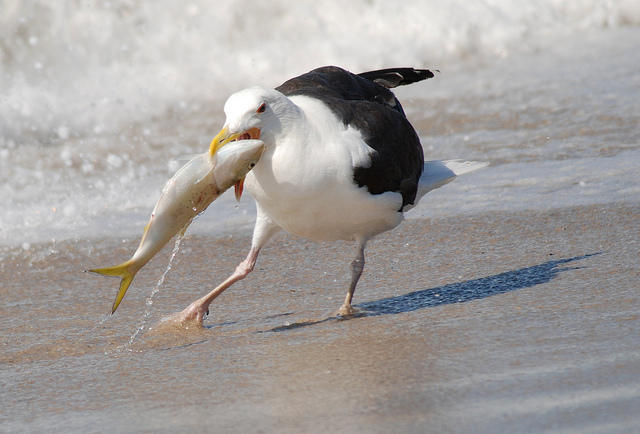

[{'bird': ['beak', 'wing', 'leg'], 'fish': ['fin', 'tail']}, {'bird': ['head'], 'fish': ['body']}]
total cost so far: 0.004195


In [8]:
image_path = os.path.join(val2017_dir, random.choice(image_files))
# image_path = "/home/jhpark/image-artifacts/hands.jpg"
openai_client = openai.OpenAI()
money_manager = MoneyManager(model='gpt-4o')
img_array = load_image_from_path(image_path)
entity_subentity_response = get_entity_subentities_new(openai_client, img_array, money_manager)

img_pil = Image.fromarray(img_array)
display(img_pil)
print(entity_subentity_response)
print("total cost so far:", money_manager.total_cost)

In [9]:
peripheral_entities = set()
peripheral_subentities = set()
peripheral_entity_subentity_mapping = defaultdict(list)
intermediate_entities = set()
intermediate_subentities = set()
intermediate_entity_subentity_mapping = defaultdict(list)
all_entity_subentity_mapping = defaultdict(list)

for entity, subentities in entity_subentity_response[0].items():
    peripheral_entities.add(entity)
    peripheral_subentities.update(subentities)
    for subentity in subentities:
        peripheral_entity_subentity_mapping[subentity].append(entity)
        all_entity_subentity_mapping[subentity].append(entity)
for entity, subentities in entity_subentity_response[1].items():
    intermediate_entities.add(entity)
    intermediate_subentities.update(subentities)
    for subentity in subentities:
        intermediate_entity_subentity_mapping[subentity].append(entity)
        all_entity_subentity_mapping[subentity].append(entity)

print(peripheral_entities)
print(peripheral_subentities)
print(peripheral_entity_subentity_mapping)
print(intermediate_entities)
print(intermediate_subentities)
print(intermediate_entity_subentity_mapping)
all_entities = peripheral_entities | intermediate_entities
all_subentities = peripheral_subentities | intermediate_subentities
print(all_entities)
print(all_subentities)
print(all_entity_subentity_mapping)

{'bird', 'fish'}
{'wing', 'beak', 'tail', 'fin', 'leg'}
defaultdict(<class 'list'>, {'beak': ['bird'], 'wing': ['bird'], 'leg': ['bird'], 'fin': ['fish'], 'tail': ['fish']})
{'bird', 'fish'}
{'head', 'body'}
defaultdict(<class 'list'>, {'head': ['bird'], 'body': ['fish']})
{'bird', 'fish'}
{'head', 'fin', 'wing', 'body', 'beak', 'tail', 'leg'}
defaultdict(<class 'list'>, {'beak': ['bird'], 'wing': ['bird'], 'leg': ['bird'], 'fin': ['fish'], 'tail': ['fish'], 'head': ['bird'], 'body': ['fish']})


Detecting parts using Grounded SAM...


Before NMS: 5 boxes
Found 2 entity detections and 3 subentity detections
Kept entity 'bird' (class 0) with area ratio 0.1355
Kept entity 'fish' (class 1) with area ratio 0.0243
Discarded subentity 'tail' - no valid entity mapping (best containment ratio: 0.000)
Mapped subentity 'head' to entity 'bird' with containment ratio 1.000
Mapped subentity 'leg' to entity 'bird' with containment ratio 1.000
After entity mapping and area ratio filtering: 2 detections remain
Returning 2 mapped subentity detections and 2 entity detections
✅ Found 2 part predictions
✅ Found 2 entity predictions
💰 Total API cost: $0.0042


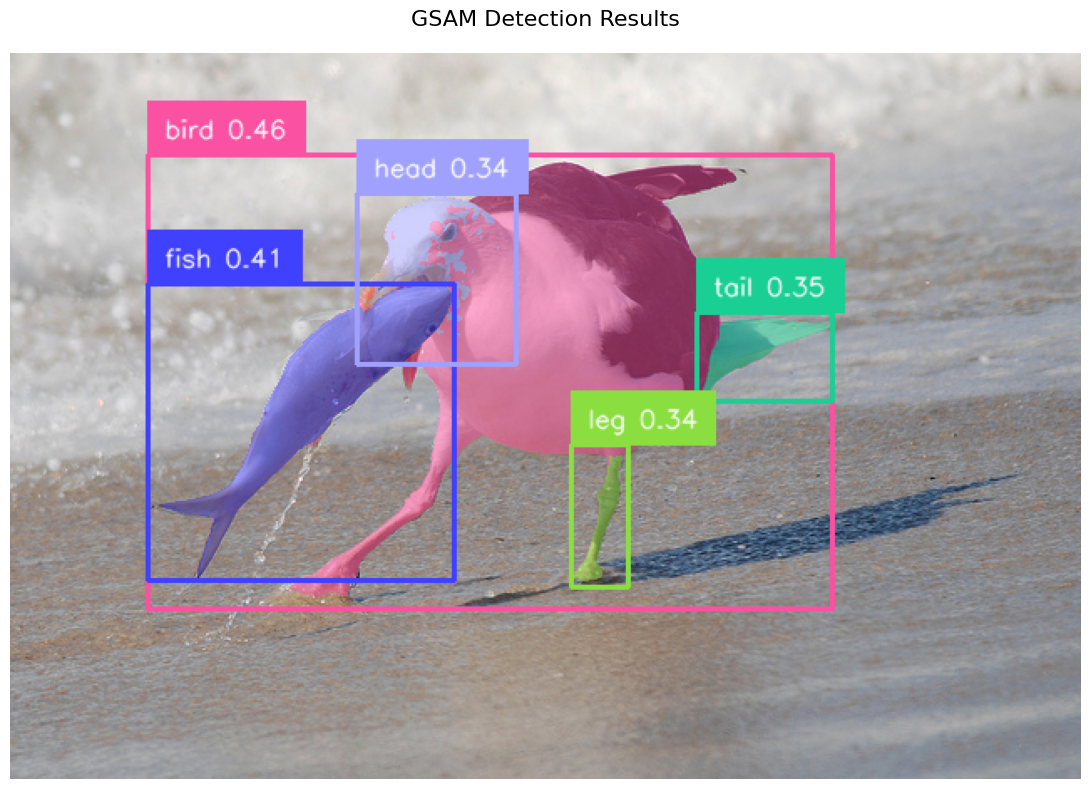

In [10]:
# Step 2: Detect parts using GSAM
print("Detecting parts using Grounded SAM...")
predictions, entity_predictions, visualized_output = gsam_detector.detect_parts(
    img_array, 
    list(all_entities), 
    list(all_subentities), 
    all_entity_subentity_mapping,
    min_area_ratio=0.005, 
    max_area_ratio=0.5
)

print(f"✅ Found {len(predictions)} part predictions")
print(f"✅ Found {len(entity_predictions)} entity predictions")
print(f"💰 Total API cost: ${money_manager.total_cost:.4f}")
# Display visualization
import matplotlib.pyplot as plt
    
# Display the visualization
plt.figure(figsize=(12, 8))
plt.imshow(visualized_output)
plt.axis('off')
plt.title('GSAM Detection Results', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [11]:
import matplotlib.pyplot as plt

mask = entity_predictions[2]['pred_mask']
if hasattr(mask, 'cpu'):
    mask = mask.cpu()
if hasattr(mask, 'numpy'):
    mask = mask.numpy()

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.title('Entity Prediction Mask')
plt.show()

IndexError: list index out of range

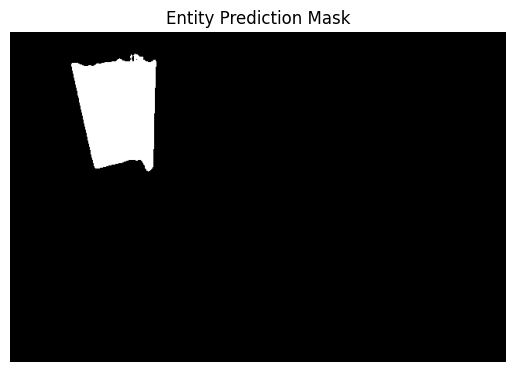

In [ ]:
import matplotlib.pyplot as plt

mask = entity_predictions[1]['pred_mask']
if hasattr(mask, 'cpu'):
    mask = mask.cpu()
if hasattr(mask, 'numpy'):
    mask = mask.numpy()

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.title('Entity Prediction Mask')
plt.show()

In [ ]:
sum(entity_predictions[1]['pred_mask'] & entity_predictions[2]['pred_mask']).sum()

tensor(0)

In [ ]:
from batch_gsam_segmentation import create_fusion_artifact_annotations

for entity_prediction in entity_predictions:
    entity = entity_prediction['entity']
    # subentity = entity_prediction['subentity']
    try:
        print(entity, subentity)
        annotation = create_fusion_artifact_annotations(
            entity_prediction, predictions,
            entity_predictions, entity, img_array,
            './notebooks/img', 'testing.jpg'
        )
    except Exception as e:
        print(e)


sandwich glass
No valid overlapping entity found for fusion artifact
drink glass
No valid overlapping entity found for fusion artifact
sandwich glass
No valid overlapping entity found for fusion artifact


In [ ]:
annotation

{'artifact_type': 'fusion',
 'entity': 'person',
 'subentity': None,
 'target_bbox': (0, 0, 0, 0),
 'reference_bbox': (0, 0, 0, 0),
 'target_patch_indices': [],
 'reference_patch_indices': [],
 'target_mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'reference_mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'distortion_kernel': None,
 'fusion_metadata': {'entity_A': 'person',
  'entity_B': 'person',
  'overlap_ratio': 0.05,
  'num_overlapping_candidates': 1,
  'target_regions': {'A_only': 0, 'B_only': 0, 'overlap': 0},
  'reference_pools': {'A_only': 0, 'B_only': 0, 'full': 0}}}